In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NumPy


## Exercício 1

In [141]:
vetor = np.random.randint(0,101,20)

In [142]:
media = np.mean(vetor)
print(f'A média do vetor é de {media}')

sd = np.std(vetor).round(2)
print(f'O desvio padrão do vetor é de {sd}')

maximo = np.max(vetor)
print(f'O maior valor do vetor é {maximo}')

A média do vetor é de 51.0
O desvio padrão do vetor é de 29.41
O maior valor do vetor é 98


## Exercício 2


In [143]:
A = np.random.normal(0, 1, (5,5))

In [144]:
linhas = np.sum(A, axis=1)
print(f'A soma das linhas é {linhas}')

colunas = np.sum(A, axis=0)
print(f'A soma das colunas é {colunas}')

A soma das linhas é [ 0.28815009 -2.42513596 -0.04749056 -3.87522496  3.3490241 ]
A soma das colunas é [ 0.7727802   2.02757303 -1.32717312 -4.30405746  0.12020006]


In [145]:
A.diagonal()

array([ 0.19316767, -0.98423898, -0.04098068, -2.23374707,  2.77942974])

## Exercício 3


In [146]:
def geometria (v1, v2):
    produto_escalar = np.dot(v1, v2)
    distancia = np.linalg.norm(v1 - v2)

    return produto_escalar.round(2), distancia.round(2)



In [147]:
v1 = np.array([2, 4, 8])
v2 = np.array([1, 3, 6])

geometria(v1,v2)

(np.int64(62), np.float64(2.45))

## Exercício 4

In [148]:
A = np.random.randint(-5, 6, (4,4))

det = np.linalg.det(A)
print("Determinante:", det)

if det != 0:
    A_inv = np.linalg.inv(A)
    print("A * A_inv =")
    print(A @ A_inv)

Determinante: 306.0
A * A_inv =
[[ 1.00000000e+00 -1.11022302e-16  2.22044605e-16 -1.66533454e-16]
 [ 5.55111512e-17  1.00000000e+00 -5.55111512e-17  0.00000000e+00]
 [ 0.00000000e+00  2.22044605e-16  1.00000000e+00 -5.55111512e-17]
 [-2.22044605e-16  2.22044605e-16 -1.11022302e-16  1.00000000e+00]]


## Exercício 5

In [149]:
M = np.random.rand(5,5)
B = (M + M.T) / 2

val, vec = np.linalg.eig(B)

# verificar Bv = λv
print(np.allclose(B @ vec, vec * val))


True


## Exercício 6

In [150]:
A = np.random.rand(3,3)
y = np.random.randint(0,10,3)

x = np.linalg.solve(A, y)

# verificar erro
erro = np.linalg.norm(np.dot(A, x) - y)
erro

np.float64(8.881784197001252e-16)

## Exercício 7

In [151]:
X = np.random.randn(2,100)

S = np.cov(X)

val, vec = np.linalg.eig(S)

print(val)
print(vec)

[1.05757349 0.6876997 ]
[[ 0.83463196  0.55080804]
 [-0.55080804  0.83463196]]


Text(0, 0.5, 'X2')

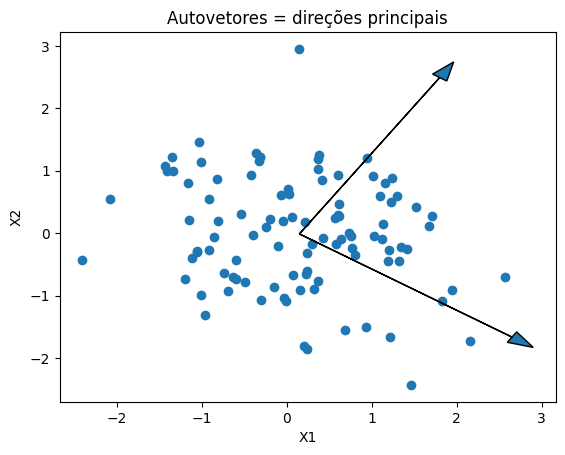

In [152]:
# mostre que os autovertores correspondem às direções principais da variabilidade dos dados
plt.scatter(X[0], X[1])

# média (centro dos dados)
media = X.mean(axis=1)

# desenhar autovetores
for i in range(2):
    v = vec[:, i]
    plt.arrow(media[0], media[1],
              v[0]*3, v[1]*3,
              head_width=0.2)

plt.title('Autovetores = direções principais')
plt.xlabel('X1')
plt.ylabel('X2')

# Pandas

## Exercício 1

In [153]:
iris = pd.read_csv(r"C:\Users\bella\Downloads\iris.csv")

iris.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [154]:
# informações sobre o dataset
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [155]:
# soma de NAs
iris.isna().sum()

sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

## Exercício 2

In [156]:
# média e desvio padrão do comprimento da pétala por espécie

media_petala = iris.groupby('variety')['petal.length'].mean()
sd_petala = iris.groupby('variety')['petal.length'].std()

print(f'A média do comprimento da pétala por espécie é:\n{media_petala}')

print(f'O desvio padrão do comprimento da pétala por espécie é:\n{sd_petala}')

A média do comprimento da pétala por espécie é:
variety
Setosa        1.462
Versicolor    4.260
Virginica     5.552
Name: petal.length, dtype: float64
O desvio padrão do comprimento da pétala por espécie é:
variety
Setosa        0.173664
Versicolor    0.469911
Virginica     0.551895
Name: petal.length, dtype: float64


In [157]:
#ordenar por média do comprimento da pétala
media_petala.sort_values(ascending=True)

variety
Setosa        1.462
Versicolor    4.260
Virginica     5.552
Name: petal.length, dtype: float64

## Exercício 3

In [158]:
dicionario = {'nome': ['Isabella', 'Gabriella', 'Gláucia'], 'idade': [23, 25, 49], 'cidade': ['São Carlos', 'Belo Horizonte', 'Teixeiras']}
df = pd.DataFrame(dicionario)

In [159]:
df['idade_quadrado'] = [x**2 for x in df['idade']]
df

,nome,idade,cidade,idade_quadrado
0,Isabella,23,São Carlos,529
1,Gabriella,25,Belo Horizonte,625
2,Gláucia,49,Teixeiras,2401


In [160]:
df = df.drop('idade_quadrado', axis=1)
df

,nome,idade,cidade
0,Isabella,23,São Carlos
1,Gabriella,25,Belo Horizonte
2,Gláucia,49,Teixeiras


## Exercício 4

In [161]:
df_idade_30mais =df.query('idade > 30')
df_idade_30mais

,nome,idade,cidade
2,Gláucia,49,Teixeiras


In [162]:
df_idade_30mais.shape

(1, 3)

## Exercício 5

In [163]:
notas = {'Aluno': ['Fulano', 'Ciclano', 'Beltrano'], 'ADED': [7.5, 8.0, 6.0], 'Cálculo': [8.0, 7.5, 6.5], 'Probabilidade': [9.0, 8.5, 7.0]}
notas_df = pd.DataFrame(notas)
notas_df

,Aluno,ADED,Cálculo,Probabilidade
0,Fulano,7.5,8.0,9.0
1,Ciclano,8.0,7.5,8.5
2,Beltrano,6.0,6.5,7.0


In [164]:
# média de cada aluno
notas_df['Média_Aluno'] = notas_df[['ADED', 'Cálculo', 'Probabilidade']].mean(axis=1).round(2)
notas_df

,Aluno,ADED,Cálculo,Probabilidade,Média_Aluno
0,Fulano,7.5,8.0,9.0,8.17
1,Ciclano,8.0,7.5,8.5,8.00
2,Beltrano,6.0,6.5,7.0,6.50


In [165]:
# média por disciplina
notas_df['Média_Disciplina'] = notas_df[['ADED', 'Cálculo', 'Probabilidade']].values.mean().round(2)
notas_df



,Aluno,ADED,Cálculo,Probabilidade,Média_Aluno,Média_Disciplina
0,Fulano,7.5,8.0,9.0,8.17,7.56
1,Ciclano,8.0,7.5,8.5,8.00,7.56
2,Beltrano,6.0,6.5,7.0,6.50,7.56


## Exercício 6

In [166]:
iris.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [167]:
iris = iris[['petal.length','petal.width']]

def normalizar(coluna):
    return (coluna - coluna.min()) / (coluna.max() - coluna.min())

iris.apply(normalizar)

,petal.length,petal.width
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667
...,...,...
145,0.711864,0.916667
146,0.677966,0.750000
147,0.711864,0.791667
148,0.745763,0.916667


## Exercício 7

In [168]:
vendas = {'produto': ['Notebook', 'Smartphone', 'Tablet'], 'preço': [2500, 1500, 1200], 'quantidade': [10, 20, 15]}
vendas = pd.DataFrame(vendas)
vendas

,produto,preço,quantidade
0,Notebook,2500,10
1,Smartphone,1500,20
2,Tablet,1200,15


In [169]:
vendas['receita'] = vendas['preço'] * vendas['quantidade']
vendas

,produto,preço,quantidade,receita
0,Notebook,2500,10,25000
1,Smartphone,1500,20,30000
2,Tablet,1200,15,18000


In [170]:
vendas.groupby('produto')['receita'].sum()

produto
Notebook      25000
Smartphone    30000
Tablet        18000
Name: receita, dtype: int64

In [171]:
# ordem do mais vendido para o menos vendido
vendas.groupby('produto')['quantidade'].sum().sort_values(ascending=False)

produto
Smartphone    20
Tablet        15
Notebook      10
Name: quantidade, dtype: int64

## Exercício 8 

In [172]:
iris.columns

Index(['petal.length', 'petal.width'], dtype='str')

In [173]:
iris = pd.read_csv(r"C:\Users\bella\Downloads\iris.csv")

In [174]:
df_setosa = iris[iris['variety'] == 'Setosa']
df_setosa.to_csv('setosa.csv', index=False)
df_setosa = pd.read_csv('setosa.csv')

In [175]:
df_setosa.shape

(50, 5)

# Matplotlib

Text(0, 0.5, 'Frequência')

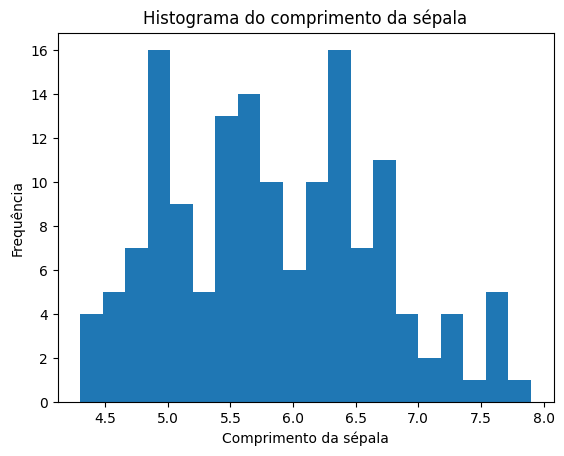

In [176]:
iris = pd.read_csv(r"C:\Users\bella\Downloads\iris.csv")
plt.hist(iris['sepal.length'], bins=20)
plt.title('Histograma do comprimento da sépala')
plt.xlabel('Comprimento da sépala')
plt.ylabel('Frequência')

## Exercício 2

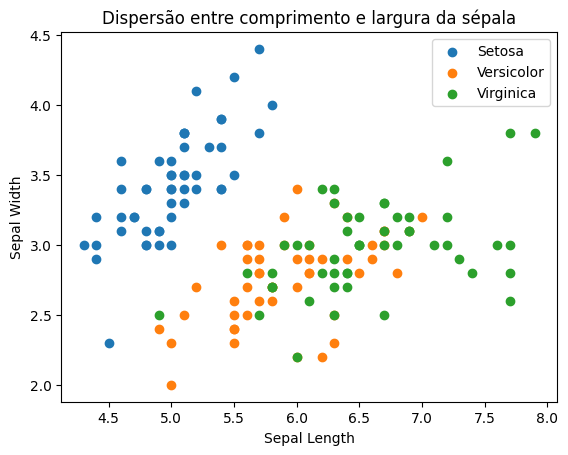

In [177]:
for especie in iris['variety'].unique():
    subset = iris[iris['variety'] == especie]
    plt.scatter(subset['sepal.length'], subset['sepal.width'], label=especie)

plt.title('Dispersão entre comprimento e largura da sépala')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.show()

## Exercício 3

Text(0.5, 1.0, 'Dispersão entre comprimento e largura da pétala')

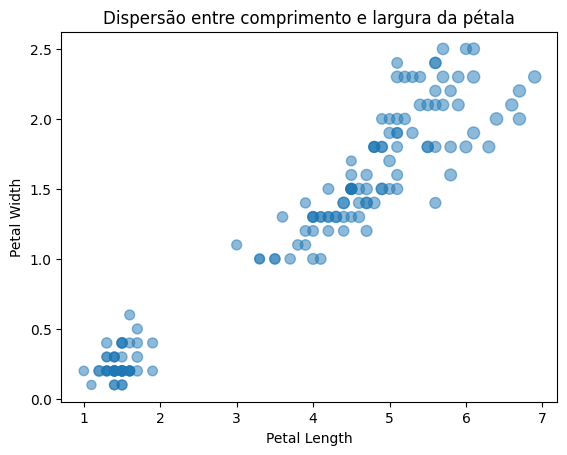

In [178]:
plt.scatter(iris['petal.length'], iris['petal.width'], s=iris['sepal.length']*10, alpha=0.5)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Dispersão entre comprimento e largura da pétala')

## Exercício 4

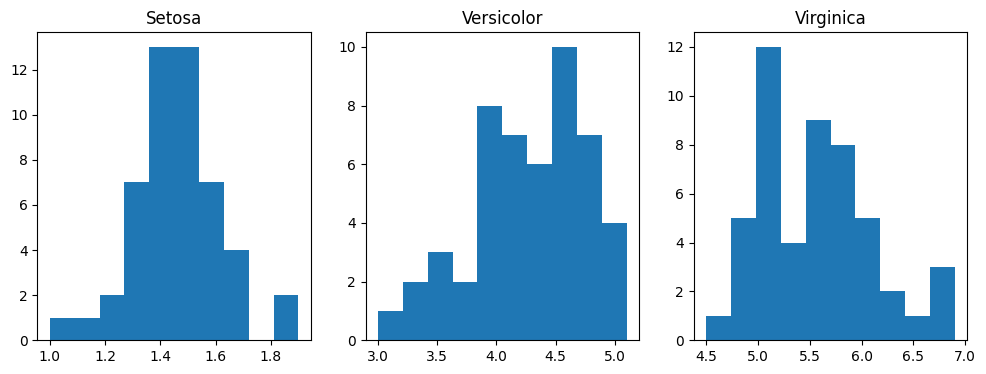

In [179]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(iris[iris['variety']=='Setosa']['petal.length'])
plt.title('Setosa')

plt.subplot(1,3,2)
plt.hist(iris[iris['variety']=='Versicolor']['petal.length'])
plt.title('Versicolor')

plt.subplot(1,3,3)
plt.hist(iris[iris['variety']=='Virginica']['petal.length'])
plt.title('Virginica')

plt.show()

## Exercício 5

C:\Users\bella\AppData\Local\Temp\ipykernel_26896\3095237704.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([iris[c] for c in caracteristicas], labels=['Comprimento Sépala', 'Largura Sépala', 'Comprimento Pétala', 'Largura Pétala'])


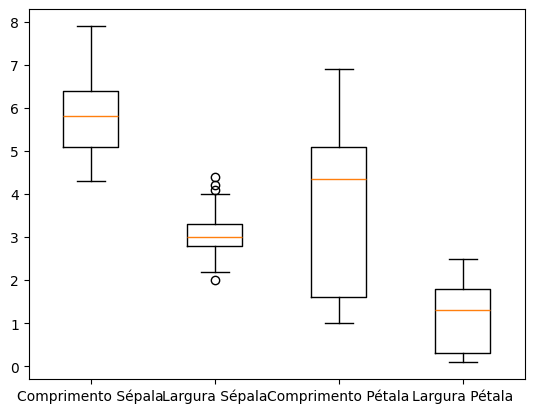

In [180]:
caracteristicas = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
plt.boxplot([iris[c] for c in caracteristicas], labels=['Comprimento Sépala', 'Largura Sépala', 'Comprimento Pétala', 'Largura Pétala'])
plt.show()

A característica de maior variabilidade é o comprimento da pétala, dada sua maior amplitude entre os quartis do boxplot.

## Exercício 6

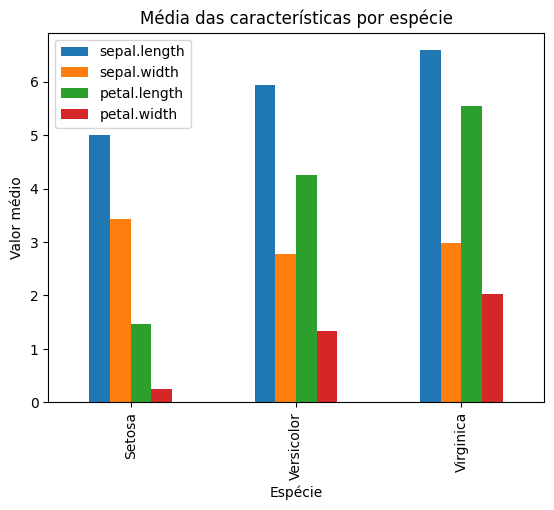

In [181]:
iris.groupby('variety')[caracteristicas].mean().plot(kind='bar')
plt.title('Média das características por espécie')
plt.xlabel('Espécie')
plt.ylabel('Valor médio')
plt.show()

## Exercício 7

In [182]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

cores = {'Setosa': 'pink', 'Versicolor': 'lightgreen', 'Virginica': 'lightblue'}

for especie, cor in cores.items():
    subset = iris[iris['variety'] == especie]
    
    ax.scatter(
        subset['sepal.length'],
        subset['sepal.width'],
        subset['petal.length'],
        color=cor,
        label=especie
    )

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('Dispersão 3D)

ax.legend()

SyntaxError: unterminated string literal (detected at line 22) (137355479.py, line 22)